In [ ]:
import numpy as np
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit.circuit.library.standard_gates import RYGate, IGate
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer.primitives import Sampler
from bigtree import BinaryNode, preorder_iter


In [4]:
def get_projectionprobs(f, n, projection_bit):
    #f .... boolean function on n bits
    p_proj = 0
    p_full = 0
    for i in range(2**n):
        argument = []
        for k in range(n):
            argument+= [i//2**(n-1-k)] 
            i = i % 2**(n-1-k)
        if argument[projection_bit] == 0:
            p_proj += f(argument)
        p_full += f(argument)
    
    #Define restricted functions
    def f_one(tupel):
        t = tupel.copy()
        t.insert(projection_bit,1)
        return f(t)
    
    def f_zero(tupel):
        t = tupel.copy()
        t.insert(projection_bit,0)
        return f(t)
    
    if p_full > 0:
        p = round(p_proj/p_full,2)
    else:
        p = -1
    
    return p, f_zero, f_one 

def get_fulltree(f,n,prefix=""):
    p, f_left, f_right = get_projectionprobs(f, n, 0)
    if p>= 0:
        root = BinaryNode(prefix, p = p)
       # print(prefix,"\t n=",n,"p=",p)
    
    else:
        return
    
    if n > 1:
        root.children = [get_fulltree(f_left,n-1,prefix+"0"),get_fulltree(f_right,n-1,prefix+"1")]
    #if n == 1:
    #    print(f([0]), f([1]))   
    return root

In [5]:
def test_bool(tupel):
    return (tupel[0] and tupel[1]) or (tupel[0] and tupel[2]) or  (tupel[1] and tupel[2])
    
def test_one(tupel):
    return 1

def test_or(tupel):
    return (tupel[0] or tupel[1])

def test_and(tupel):
    return (tupel[0] and tupel[1])

def test_range(a,b):
    # a..start, b..end, n .. size of tupel
    
    def f(tupel):
        x = ''.join([str(digit) for digit in tupel])[::-1]
        if a <= int(x,2) and int(x,2) < b:
            return 1
        else: 
            return 0
    return f

def test_k_out_n(k, n):

    def f(tupel):
        assert len(tupel) == n, "n inputs expected"
        summe =sum(tupel)
        return int(summe >= k)
    return f


In [6]:
f = test_k_out_n(2,4)
get_fulltree(test_k_out_n(2,4),4).show(attr_list=['p'])

 [p=0.36]
├── 0 [p=0.25]
│   ├── 00 [p=0.0]
│   │   └── 001 [p=0.0]
│   └── 01 [p=0.33]
│       ├── 010 [p=0.0]
│       └── 011 [p=0.5]
└── 1 [p=0.43]
    ├── 10 [p=0.33]
    │   ├── 100 [p=0.0]
    │   └── 101 [p=0.5]
    └── 11 [p=0.5]
        ├── 110 [p=0.5]
        └── 111 [p=0.5]


In [7]:
   
def valid_cards_2players(card_tupel, cards_in_player_hands=[2,2], total_number_of_cards = 4, report = False):
    # cards ordered descending (highest card first), no trump cards

    ### states:
    # 00i hand player i
    # 01i played by player i
    # 11i stack of player
    # 100 not distributed
  
    assert sum(cards_in_player_hands) <= total_number_of_cards
    c = total_number_of_cards #total number of cards
    s = 3 #number of playerstate-bits
    n =  c*s #length of tupel
    #assert len(card_tupel) == n
    
    
    eval_op = 0
    cards = []
    for i in range(c):
        cards += [''.join([str(bit) for bit in card_tupel[3*i:3*(i+1)]])]
        
    #number of cards in hand
    check = [0,0,0] # not in play, player 1 , player 2
    for card in cards:
        if card == '000':
            check[1] += 1
        elif card == '001':
            check[2] += 1
        elif card == '100':       
            check[0] += 1

    condition = (check[1] == cards_in_player_hands[0]) and (check[2] == cards_in_player_hands[1])

     #nur ein beispiel

    cards_player0 = [i for i, card in enumerate(cards) if card == '110']
    cards_player1 = [i for i, card in enumerate(cards) if card == '111']

    for i in range(len(cards_player0)):
        start_vec = np.zeros(n-3) # platz für eine karte
        proj_vec = np.insert(start_vec,3*i,[1,1,0])
        state = Statevector(proj_vec)
        #print(state)
        eval_op = state.to_operator()

    
    if report:
        print('cards:', cards)
        print('# cards player 1, # cards player 2, # cards not in play:', check)
        print(eval_op)

    return int(condition)

valid_cards_2players('000001000001')  


def make_qsp(f,n,circuit, showtree=False):
    gates = get_fulltree(f,n) 
    if showtree:
        gates.show(attr_list=['p'])
        
    for node in preorder_iter(gates):
        
        cond = node.node_name[::-1] # string, aber noch in umgkehrter reihenfolge
        p = node.get_attr("p")
        work_qubit = node.depth-1
        cond_qubits = range(0,work_qubit)
        
        # print(work_qubit, cond_qubits, cond,p)
        
        theta = 2*np.arccos(np.sqrt(p))
        if node.is_root:
            p_gate = RYGate(theta)
        else:
            p_gate = RYGate(theta).control(len(cond), ctrl_state=cond )
        
        circuit.append(p_gate, range(node.depth))

    
    

N= 3
qr = QuantumRegister(N)
cr = ClassicalRegister(N)
qc = QuantumCircuit(qr, cr)    
make_qsp(test_range(2,4),3,qc)
#make_qsp(test_bool,3,qc)


qc.measure(range(N), range(N))
qc = qiskit.compiler.transpile(qc, optimization_level=2)
qc.draw()


┌─────────┐                                    ┌─┐      
q0_0: ┤ Ry(π/2) ├────o────────o────────■────────■────┤M├──────
      └─────────┘┌───┴───┐    │    ┌───┴───┐    │    └╥┘┌─┐   
q0_1: ───────────┤ Ry(π) ├────■────┤ Ry(π) ├────■─────╫─┤M├───
                 └───────┘┌───┴───┐└───────┘┌───┴───┐ ║ └╥┘┌─┐
q0_2: ────────────────────┤ Ry(0) ├─────────┤ Ry(0) ├─╫──╫─┤M├
                          └───────┘         └───────┘ ║  ║ └╥┘
c0: 3/════════════════════════════════════════════════╩══╩══╩═
                                                      0  1  2

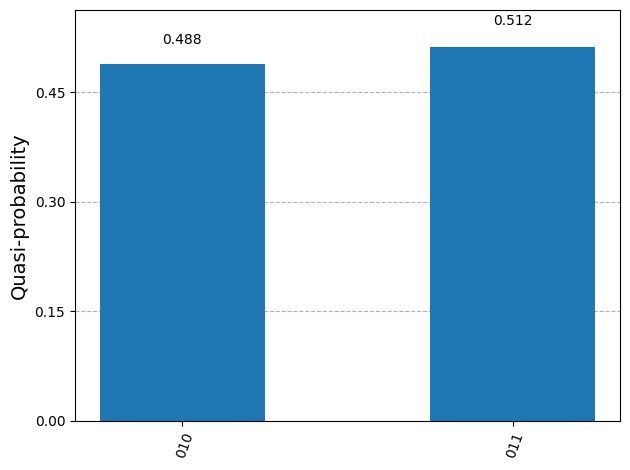

In [8]:
results = Sampler().run(qc).result()
statistics = results.quasi_dists[0].binary_probabilities()
display(plot_histogram(statistics))

In [9]:

def make_bool_from_valid_cards_2players(cards ,N):
    def f(tupel):
        card_tupel = ''
        for i in range(len(tupel)):
            card_tupel += str(tupel[i])
        #print(card_tupel)
        return valid_cards_2players(card_tupel, cards_in_player_hands=cards, total_number_of_cards=N )

    return f

s = '000001000001'
t = [int(b) for b in s]
f = make_bool_from_valid_cards_2players([2,1],3)
f(t)

1

In [10]:
start_sp = []
for N in range(3,7):
    f = make_bool_from_valid_cards_2players([2,1],N)
    num_qubits = 3*N
    start_sp.append([f,num_qubits])

len(start_sp)

4

In [ ]:
from qiskit import transpile
cnot_count = []
for instance in start_sp:
    f= instance[0]
    N= instance[1]

    qr = QuantumRegister(N)
    cr = ClassicalRegister(N)
    qc = QuantumCircuit(qr, cr)    
    make_qsp(f,N,qc)


    level = 1
    qc_basic = transpile(
    qc,
    basis_gates=["u", "cx"],   # common basic set
    optimization_level=level)

    count = qc_basic.count_ops()
    print(f"{N//3} cards total, level {level}:", count)
    cnot_count.append([N, count['cx']])


3 cards total, level 1: OrderedDict([('u', 1015), ('cx', 864)])
4 cards total, level 1: OrderedDict([('u', 38630), ('cx', 33132)])
5 cards total, level 1: OrderedDict([('u', 697165), ('cx', 611724)])
6 cards total, level 1: OrderedDict([('u', 9318343), ('cx', 8351724)])


In [13]:
print(cnot_count)

[[9, 864], [12, 33132], [15, 611724], [18, 8351724]]


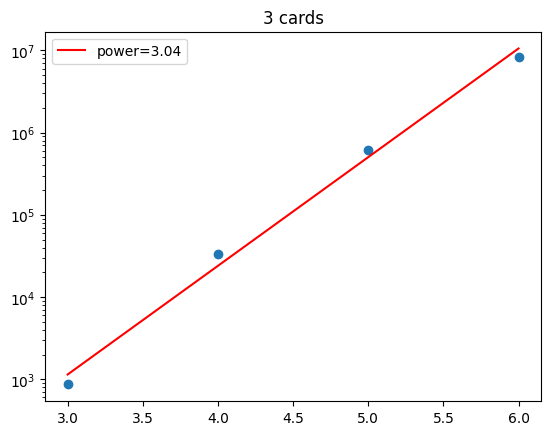

In [32]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

x = np.array([cnot_count[i][0]//3 for i in range(len(cnot_count))])
y = np.array([cnot_count[i][1] for i in range(len(cnot_count))])

x=x.reshape(-1,1)
model = LinearRegression()
model.fit(x, np.log(y))
x_regression = np.linspace(3,6,100).reshape(-1,1)
y_regression = model.predict(x_regression)
plt.scatter(x,y)
plt.plot(x_regression,np.exp(y_regression), color = "red", label = f"power={model.coef_[0]:.2f}")
plt.yscale("log")
plt.title("3 cards")
plt.legend()
plt.show()


In [ ]:
qc.measure(range(N), range(N))
#qc.draw()
results = Sampler().run(qc).result()
statistics = results.quasi_dists[0].binary_probabilities()
#display(plot_histogram(statistics))
